In [1]:
# Cell 1: Load the delineated watershed products and prepare screening output folders.
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from shapely.geometry import LineString
import whitebox

cwd = Path.cwd()
project_dir = cwd.parent if cwd.name.lower() in {"notebook", "notebooks"} else cwd
results_dir = project_dir / "results"
preprocessing_dir = results_dir / "preprocessing"
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

dem_path = preprocessing_dir / "watershedDEM.tif"
dem_filled = str((preprocessing_dir / "filledDEM.tif").resolve())
flow_direction = str((preprocessing_dir / "flowPointer.tif").resolve())
flow_accumulation = str((preprocessing_dir / "flowAccumulation.tif").resolve())
watershed_raster = str((preprocessing_dir / "watershed.tif").resolve())
watershed_boundary_path = preprocessing_dir / "watershedBoundary.shp"
pourpoint_path = preprocessing_dir / "outlet_snapped.shp"

wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(True)
wbt.set_working_dir(str(preprocessing_dir.resolve()))

print("Watershed DEM:", dem_path.resolve())
print("Delineation products:", preprocessing_dir.resolve())

Watershed DEM: D:\HydropowerScreening\results\preprocessing\watershedDEM.tif
Delineation products: D:\HydropowerScreening\results\preprocessing


In [2]:
# Cell 2: Validate the delineation products and initialize the common UTM grid.
required_paths = (
    dem_path,
    Path(dem_filled),
    Path(flow_direction),
    Path(flow_accumulation),
    Path(watershed_raster),
    watershed_boundary_path,
    pourpoint_path,
)
for required_path in required_paths:
    if not required_path.exists():
        raise FileNotFoundError(f"Run notebook 02 first; required preprocessing output is missing: {required_path}")

with rasterio.open(dem_path) as src:
    dem_crs = src.crs
    dem_res = src.res
    dem_bounds = src.bounds
    dem_band = src.read(1, masked=True)
if dem_crs is None:
    raise ValueError("The delineated DEM has no CRS.")
if dem_band.count() == 0:
    raise ValueError("The delineated DEM contains no valid elevation cells.")

pourpoint = gpd.read_file(pourpoint_path)
if len(pourpoint) != 1 or pourpoint.geometry.iloc[0] is None or pourpoint.geometry.iloc[0].geom_type != "Point":
    raise ValueError("The preprocessed outlet must contain exactly one point.")
if pourpoint.crs is None or pourpoint.crs != dem_crs:
    raise ValueError("The preprocessed outlet CRS must match the delineated DEM CRS.")
px, py = pourpoint.geometry.iloc[0].x, pourpoint.geometry.iloc[0].y
inside = (dem_bounds.left <= px <= dem_bounds.right) and (dem_bounds.bottom <= py <= dem_bounds.top)
if not inside:
    raise ValueError("The preprocessed outlet falls outside the delineated watershed DEM.")
snap_x, snap_y = px, py

routing_grid = None
with rasterio.open(dem_filled) as src:
    if src.crs != dem_crs:
        raise ValueError("The filled DEM CRS does not match the delineated DEM CRS.")
    routing_grid = (src.crs, src.transform, src.width, src.height)

for raster_path in (flow_direction, flow_accumulation, watershed_raster):
    with rasterio.open(raster_path) as src:
        if (src.crs, src.transform, src.width, src.height) != routing_grid:
            raise ValueError(f"Preprocessing raster is not aligned to the filled DEM: {raster_path}")

with rasterio.open(flow_accumulation) as src:
    cell_area_km2 = abs(src.res[0] * src.res[1]) / 1_000_000
if cell_area_km2 <= 0:
    raise ValueError("The flow-accumulation raster has an invalid cell area.")

print("Delineated DEM CRS:", dem_crs)
print("DEM resolution:", dem_res)
print("DEM elevation range:", dem_band.min(), "-", dem_band.max())
print("Outlet inside delineated DEM:", inside)
print("Cell area (km²):", cell_area_km2)

Delineated DEM CRS: EPSG:32644
DEM resolution: (30.0, 30.0)
DEM elevation range: 182.5 - 8132.9116
Outlet inside delineated DEM: True
Cell area (km²): 0.0009


In [3]:
# Cell 3: Stream initiation threshold — literature-informed choice (1 km²), validated against
# slope-break analysis of the contributing-area distribution within the watershed
stream_threshold_km2 = 1.0
stream_threshold_cells = int(round(stream_threshold_km2 / cell_area_km2))
print(f"Stream threshold: {stream_threshold_km2} km² = {stream_threshold_cells} cells")
print("Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution")
print("mountainous terrain (0.5-1 km²); automated slope-break detection was inconclusive")
print("(bimodal, noise-affected), so this value was chosen deliberately and is documented as such.")

Stream threshold: 1.0 km² = 1111 cells
Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution
mountainous terrain (0.5-1 km²); automated slope-break detection was inconclusive
(bimodal, noise-affected), so this value was chosen deliberately and is documented as such.


In [4]:
# Cell 4: Extract the screened stream network within the delineated watershed.
with rasterio.open(flow_accumulation) as src:
    facc_full = src.read(1)
    profile = src.profile
if profile.get("nodata") is None:
    raise ValueError("The flow-accumulation raster must define NoData before stream raster creation.")

with rasterio.open(watershed_raster) as src:
    ws_data = src.read(1)
    ws_nodata = src.nodata
    ws_res = src.res
valid_ws_mask_full = np.isfinite(ws_data) & (ws_data > 0)
if ws_nodata is not None:
    valid_ws_mask_full &= ws_data != ws_nodata
if not valid_ws_mask_full.any():
    raise ValueError("The preprocessed watershed raster contains no watershed cells.")
ws_area_km2 = valid_ws_mask_full.sum() * abs(ws_res[0] * ws_res[1]) / 1_000_000

stream_data = np.where(
    (facc_full >= stream_threshold_cells) & valid_ws_mask_full,
    1,
    profile["nodata"],
).astype(profile["dtype"])
stream_network_raster = str((preprocessing_dir / "stream_network.tif").resolve())
with rasterio.open(stream_network_raster, "w", **profile) as dst:
    dst.write(stream_data, 1)

stream_vector_path = preprocessing_dir / "stream_network.shp"
for old_file in preprocessing_dir.glob(f"{stream_vector_path.stem}.*"):
    if old_file.suffix.lower() in {".shp", ".shx", ".dbf", ".prj", ".cpg"}:
        old_file.unlink()
wbt.raster_streams_to_vector(
    streams=stream_network_raster,
    d8_pntr=flow_direction,
    output=str(stream_vector_path.resolve()),
)
streams_gdf = gpd.read_file(stream_vector_path)
streams_gdf = streams_gdf.set_crs(dem_crs, allow_override=True)

river_network_gpkg = str((results_dir / "river_network.gpkg").resolve())
streams_gdf.to_file(river_network_gpkg, driver="GPKG")

with rasterio.open(flow_accumulation) as src:
    row_chk, col_chk = src.index(snap_x, snap_y)
facc_at_snap = facc_full[row_chk, col_chk]
print(f"Watershed area: {ws_area_km2:.2f} km²")
print(f"Preprocessed outlet: ({snap_x:.2f}, {snap_y:.2f})")
print(f"Contributing area at outlet: {facc_at_snap * cell_area_km2:.1f} km²")
print("Stream segments:", len(streams_gdf))
print("Total vectorized length (km):", streams_gdf.geometry.length.sum() / 1000)

.\whitebox_tools.exe --run="RasterStreamsToVector" --wd="D:\HydropowerScreening\results\preprocessing" --streams='D:\HydropowerScreening\results\preprocessing\stream_network.tif' --d8_pntr='D:\HydropowerScreening\results\preprocessing\flowPointer.tif' --output='D:\HydropowerScreening\results\preprocessing\stream_network.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
P

In [5]:
# Cell 5: Build the river network as a graph (nodes=endpoints, edges=segments); confirm tree structure
G = nx.Graph()
coord_precision = 2

def round_coord(pt, precision=coord_precision):
    return (round(pt[0], precision), round(pt[1], precision))

for idx, row in streams_gdf.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    coords = list(geom.coords)
    start = round_coord(coords[0])
    end = round_coord(coords[-1])
    G.add_edge(start, end, length=geom.length, fid=row["FID"], geometry=geom)

print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())
print("Is connected:", nx.is_connected(G))

# Identify outlet node: leaf node closest to the snapped pour point
degrees = dict(G.degree())
leaf_nodes = [n for n, d in degrees.items() if d == 1]
outlet_node = min(leaf_nodes, key=lambda n: (n[0]-snap_x)**2 + (n[1]-snap_y)**2)
print("Outlet node:", outlet_node)

Nodes: 6364 | Edges: 6363
Is connected: True
Outlet node: (837364.94, 3074040.55)


In [6]:
# Cell 6: Compute cumulative distance from outlet for every node, and build each edge's
# ancestor chain (list of edges from outlet to that edge) — needed for graph-walking sampling
# and later for the multi-scale downstream search.
node_cum_dist = {outlet_node: 0.0}
visited = {outlet_node}
queue = [outlet_node]
while queue:
    node = queue.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited:
            continue
        node_cum_dist[neighbor] = node_cum_dist[node] + G.edges[node, neighbor]["length"]
        visited.add(neighbor)
        queue.append(neighbor)

edge_near_far = {}
for u, v, data in G.edges(data=True):
    fid = data["fid"]
    near, far = (u, v) if node_cum_dist[u] < node_cum_dist[v] else (v, u)
    edge_near_far[fid] = (near, far)
edge_range = {fid: (node_cum_dist[near], node_cum_dist[far]) for fid, (near, far) in edge_near_far.items()}

edge_ancestor_chain = {}
visited_nodes = {outlet_node}
stack = [(outlet_node, [])]
while stack:
    node, chain = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited_nodes:
            continue
        fid = G.edges[node, neighbor]["fid"]
        near, far = edge_near_far[fid]
        if near != node:
            continue
        new_chain = chain + [fid]
        edge_ancestor_chain[fid] = new_chain
        visited_nodes.add(neighbor)
        stack.append((neighbor, new_chain))

print("Nodes with cumulative distance:", len(node_cum_dist))
print("Edges with ancestor chains:", len(edge_ancestor_chain), "/", G.number_of_edges())

Nodes with cumulative distance: 6364
Edges with ancestor chains: 6363 / 6363


In [7]:
# Cell 7: Sample points every 500m along the network, using cumulative graph distance
# so spacing stays continuous across confluences (not reset per segment).
sample_spacing_m = 500
river_points = []
point_id = 0
visited2 = {outlet_node}
stack = [(outlet_node, 0.0)]

while stack:
    node, cum_dist = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited2:
            continue
        edge_data = G.edges[node, neighbor]
        geom = edge_data["geometry"]
        length = edge_data["length"]

        coords = list(geom.coords)
        start_pt = round_coord(coords[0])
        if start_pt != node:
            geom = LineString(coords[::-1])

        dist_start, dist_end = cum_dist, cum_dist + length
        k_start = 0 if dist_start == 0 else int(np.ceil(dist_start / sample_spacing_m))
        k_end = int(np.floor(dist_end / sample_spacing_m))

        for k in range(k_start, k_end + 1):
            global_dist = k * sample_spacing_m
            local_dist = global_dist - dist_start
            if 0 <= local_dist <= length:
                pt = geom.interpolate(local_dist)
                river_points.append({"point_id": point_id, "edge_fid": edge_data["fid"],
                                      "cum_dist_from_outlet_m": global_dist, "geometry": pt})
                point_id += 1

        visited2.add(neighbor)
        stack.append((neighbor, dist_end))

river_points_gdf = gpd.GeoDataFrame(river_points, crs=dem_crs)
print("Total river points sampled:", len(river_points_gdf))

Total river points sampled: 16013


In [8]:
# Cell 8: Extract elevation (from filled DEM) and contributing area (discharge proxy,
# from flow accumulation) at every sampled river point.
with rasterio.open(dem_filled) as src:
    dem_arr = src.read(1)
    dem_transform = src.transform

with rasterio.open(flow_accumulation) as src:
    facc_arr = src.read(1)
    facc_transform = src.transform

elevations, contrib_areas = [], []
for geom in river_points_gdf.geometry:
    row_e, col_e = rasterio.transform.rowcol(dem_transform, geom.x, geom.y)
    elevations.append(dem_arr[row_e, col_e])
    row_f, col_f = rasterio.transform.rowcol(facc_transform, geom.x, geom.y)
    contrib_areas.append(facc_arr[row_f, col_f] * cell_area_km2)

river_points_gdf["elevation_m"] = elevations
river_points_gdf["contrib_area_km2"] = contrib_areas

river_points_gpkg = str((results_dir / "river_points.gpkg").resolve())
river_points_gdf.to_file(river_points_gpkg, driver="GPKG")

print("Elevation range:", river_points_gdf["elevation_m"].min(), "-", river_points_gdf["elevation_m"].max())
print("Contributing area range (km²):", river_points_gdf["contrib_area_km2"].min(), "-", river_points_gdf["contrib_area_km2"].max())

Elevation range: 182.89648139648432 - 6373.40185546875
Contributing area range (km²): 0.9999 - 11868.757


In [9]:
# Cell 9: For every "major" reach point (contributing area >= 100 km²), search downstream
# at every 500m increment up to 10km, keeping whichever span gives the best route-length ratio.
# This is the core methodology fix: catches loops/bends at any scale, not just fixed 500m reaches.
edge_points = {fid: g.sort_values("cum_dist_from_outlet_m").reset_index(drop=True)
               for fid, g in river_points_gdf.groupby("edge_fid")}

def find_ancestor_point(edge_fid, target_dist):
    if target_dist < 0:
        return None
    for fid in edge_ancestor_chain.get(edge_fid, []):
        lo, hi = edge_range[fid]
        if lo - 1e-6 <= target_dist <= hi + 1e-6:
            pts = edge_points.get(fid)
            if pts is None:
                return None
            match = pts[np.isclose(pts["cum_dist_from_outlet_m"], target_dist, atol=1.0)]
            return match.iloc[0] if not match.empty else None
    return None

span_options_m = list(range(500, 10001, 500))
major_points = river_points_gdf[river_points_gdf["contrib_area_km2"] >= 100].copy()

results = []
for _, p in major_points.iterrows():
    best = None
    for span in span_options_m:
        target_dist = p["cum_dist_from_outlet_m"] - span
        anc = find_ancestor_point(p["edge_fid"], target_dist)
        if anc is None:
            continue
        dz = p["elevation_m"] - anc["elevation_m"]
        if dz <= 0:
            continue
        euclid = np.hypot(p.geometry.x - anc.geometry.x, p.geometry.y - anc.geometry.y)
        if euclid <= 0:
            continue
        ratio = span / euclid
        if best is None or ratio > best["route_length_ratio"]:
            best = {
                "point_id": p["point_id"],
                "upstream_x": p.geometry.x, "upstream_y": p.geometry.y,
                "downstream_x": anc.geometry.x, "downstream_y": anc.geometry.y,
                "upstream_elevation_m": p["elevation_m"], "downstream_elevation_m": anc["elevation_m"],
                "delta_z_m": dz, "river_distance_m": span, "euclidean_distance_m": euclid,
                "river_gradient_pct": 100*dz/span, "euclidean_gradient_pct": 100*dz/euclid,
                "route_length_ratio": ratio, "contrib_area_km2": p["contrib_area_km2"],
            }
    if best is not None:
        results.append(best)

multiscale_df = pd.DataFrame(results)
print("Points searched:", len(major_points), "| Valid results:", len(multiscale_df))

Points searched: 2131 | Valid results: 2130


In [10]:
# Cell 10: Screen candidates (ratio>=2.0, ΔZ>=30m, euclidean_gradient>=3%), then deduplicate
# spatially (radius=1500m) since the same physical bend is often re-detected from multiple
# nearby starting points at different span lengths.
mask = (multiscale_df["route_length_ratio"] >= 2.0) & \
       (multiscale_df["delta_z_m"] >= 30) & \
       (multiscale_df["euclidean_gradient_pct"] >= 3)
final_candidates = multiscale_df[mask].sort_values("route_length_ratio", ascending=False).reset_index(drop=True)

dedup_radius_m = 1500
kept_indices, kept_coords = [], []
for idx, row in final_candidates.iterrows():
    pt = (row["upstream_x"], row["upstream_y"])
    if not any(np.hypot(pt[0]-kx, pt[1]-ky) < dedup_radius_m for kx, ky in kept_coords):
        kept_indices.append(idx)
        kept_coords.append(pt)

deduped_candidates = final_candidates.loc[kept_indices].reset_index(drop=True)
deduped_candidates["reach_id"] = range(len(deduped_candidates))

print("Candidates before dedup:", len(final_candidates), "| After dedup:", len(deduped_candidates))
print(deduped_candidates[["reach_id", "delta_z_m", "river_distance_m", "euclidean_distance_m",
                            "route_length_ratio", "euclidean_gradient_pct", "contrib_area_km2"]])

Candidates before dedup: 40 | After dedup: 13
    reach_id   delta_z_m  river_distance_m  euclidean_distance_m  \
0          0   62.136509              7500           1698.337049   
1          1   33.509174              3000            770.870877   
2          2   98.332561              6500           2031.060084   
3          3   89.373535              7000           2615.694103   
4          4  164.363090              9000           3582.379630   
5          5  149.783203             10000           4186.143805   
6          6  136.583648             10000           4205.126462   
7          7  204.471372              2500           1057.659923   
8          8   38.869265              2500           1156.103061   
9          9  437.189267              3500           1655.695609   
10        10  110.310410              6500           3090.738015   
11        11   37.146899              2500           1193.514894   
12        12   44.979980              2000            958.131671   

 

In [11]:
# Cell 11: Export final candidate reaches and upstream site points.
export_cols = ["reach_id", "downstream_x", "downstream_y", "upstream_x", "upstream_y",
               "downstream_elevation_m", "upstream_elevation_m", "delta_z_m",
               "river_distance_m", "euclidean_distance_m", "route_length_ratio",
               "river_gradient_pct", "euclidean_gradient_pct", "contrib_area_km2"]

deduped_candidates[export_cols].to_csv(results_dir / "candidate_reaches.csv", index=False)

candidate_reaches_gdf = gpd.GeoDataFrame(
    deduped_candidates[export_cols].copy(),
    geometry=[
        LineString(((row.upstream_x, row.upstream_y), (row.downstream_x, row.downstream_y)))
        for row in deduped_candidates.itertuples()
    ],
    crs=dem_crs,
)
candidate_reaches_gdf.to_file(results_dir / "candidate_reaches.gpkg", driver="GPKG")

candidate_sites_gdf = gpd.GeoDataFrame(
    deduped_candidates[export_cols].copy(),
    geometry=gpd.points_from_xy(deduped_candidates["upstream_x"], deduped_candidates["upstream_y"]),
    crs=dem_crs,
)
candidate_sites_gdf.to_file(results_dir / "candidate_sites.gpkg", driver="GPKG")

print(f"Exported {len(deduped_candidates)} candidate reaches.")
print("Reach lines point from upstream to downstream; site points mark each upstream end.")
print("Files: candidate_reaches.csv, candidate_reaches.gpkg, candidate_sites.gpkg, river_network.gpkg, river_points.gpkg")

Exported 13 candidate reaches.
Reach lines point from upstream to downstream; site points mark each upstream end.
Files: candidate_reaches.csv, candidate_reaches.gpkg, candidate_sites.gpkg, river_network.gpkg, river_points.gpkg


In [12]:
# Cell 12: Build the shared watershed-clipped window (bounding box + valid-data mask) used
# by every map below, so the rectangular DEM extent never appears in any figure.
with rasterio.open(watershed_raster) as src:
    ws_full = src.read(1)
    ws_nodata_val = src.nodata
    ws_transform = src.transform

valid_mask_full = (ws_full > 0) & (ws_full != ws_nodata_val)
rows_v, cols_v = np.where(valid_mask_full)
buffer_cells = 20
row_min = max(rows_v.min() - buffer_cells, 0)
row_max = min(rows_v.max() + buffer_cells, ws_full.shape[0] - 1)
col_min = max(cols_v.min() - buffer_cells, 0)
col_max = min(cols_v.max() + buffer_cells, ws_full.shape[1] - 1)

x_min, y_max = ws_transform * (col_min, row_min)
x_max, y_min = ws_transform * (col_max + 1, row_max + 1)

valid_mask_crop = valid_mask_full[row_min:row_max+1, col_min:col_max+1]

with rasterio.open(dem_filled) as src:
    dem_full = src.read(1)
dem_crop = dem_full[row_min:row_max+1, col_min:col_max+1]
dem_masked = np.ma.masked_where(~valid_mask_crop, dem_crop)

print("Clipped map extent:", (x_min, x_max, y_min, y_max))

Clipped map extent: (np.float64(683959.9370423305), np.float64(839269.9370423305), np.float64(3069915.549639882), np.float64(3248715.549639882))


Main channel length: 418.5 km
All 5 maps saved to results/figures/


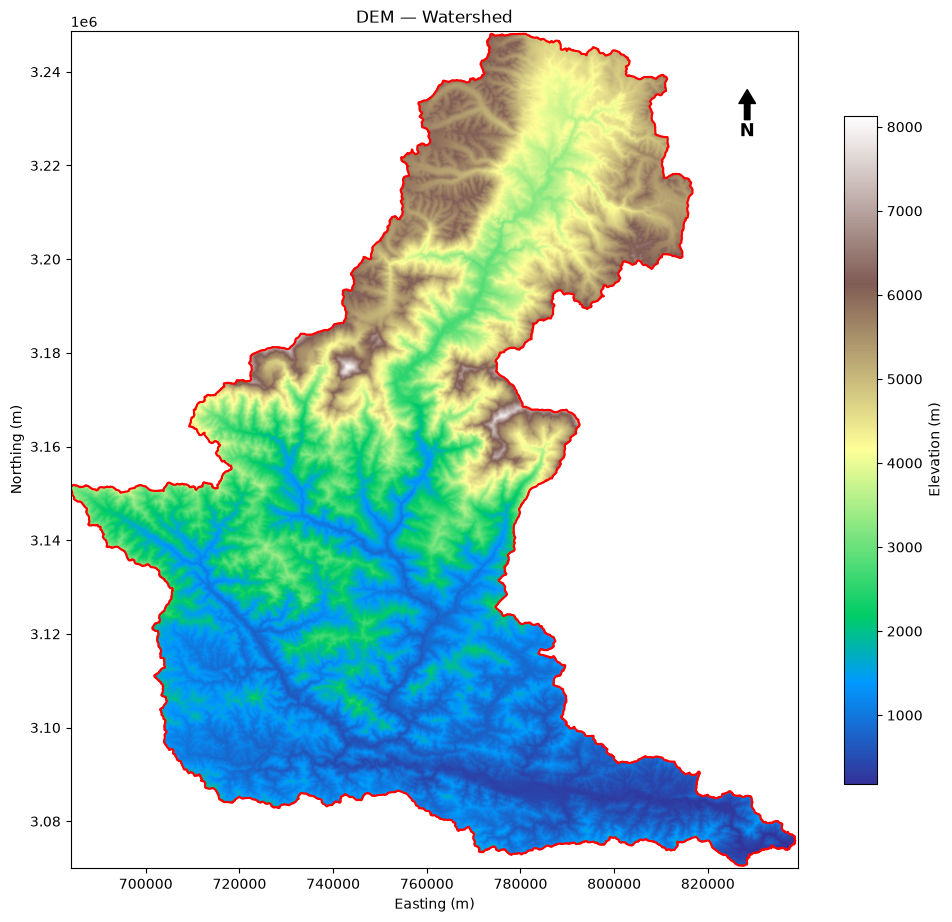

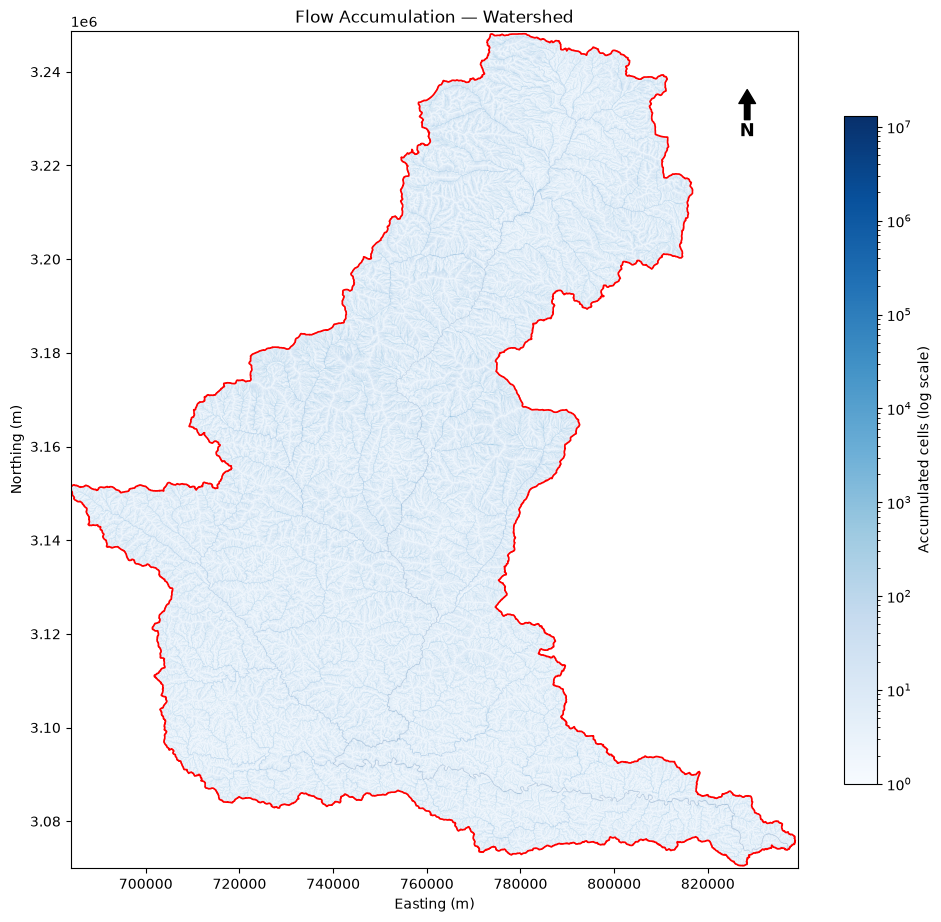

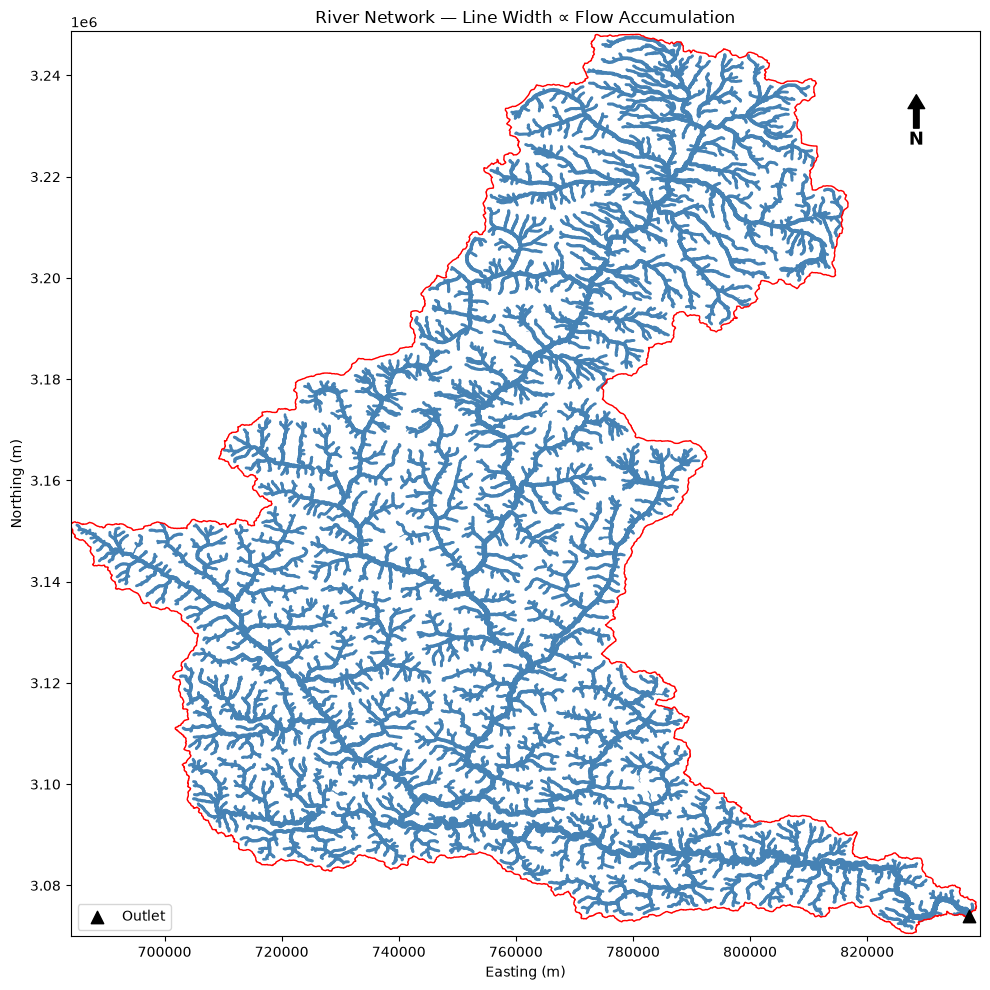

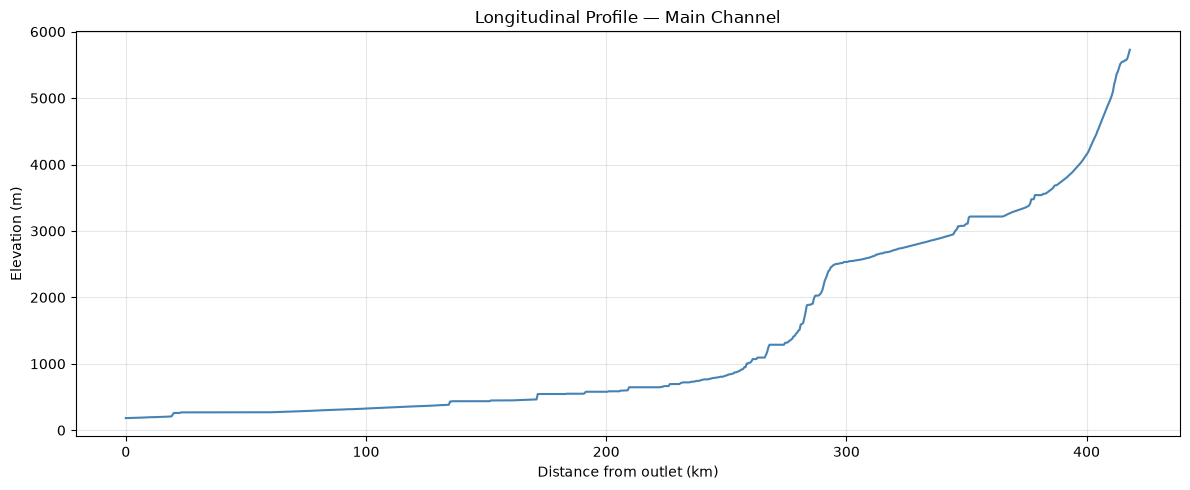

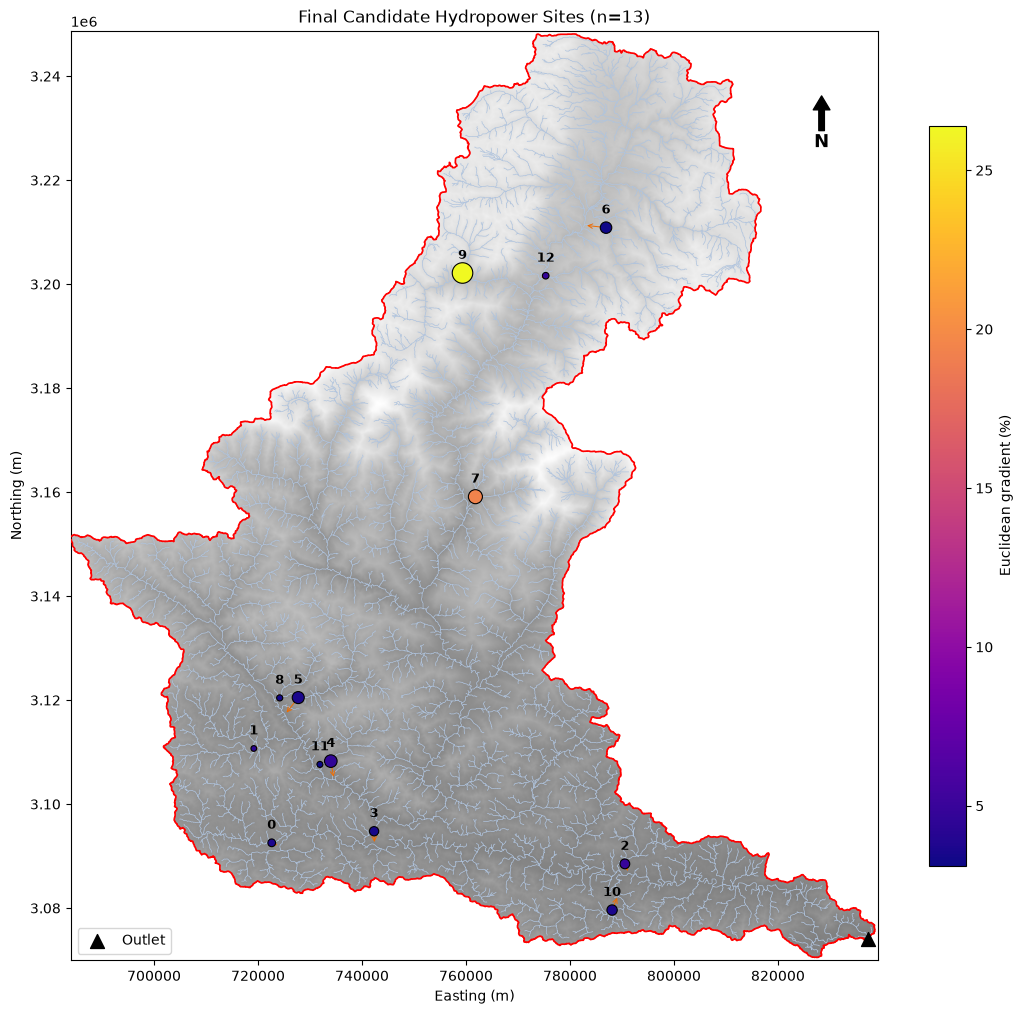

In [13]:
# Cell 13: Final visualization suite — all 5 maps, clipped to watershed boundary, with north arrows.
# (a) DEM + watershed  (b) flow accumulation  (c) river network, width by discharge
# (d) longitudinal elevation profile of main channel  (e) final candidate sites, labeled

def add_north_arrow(ax, x=0.93, y=0.93, size=0.05):
    """Simple north arrow using axes-relative coordinates (top-right)."""
    ax.annotate("N", xy=(x, y), xytext=(x, y - size),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(facecolor="black", width=4, headwidth=12, headlength=10),
                ha="center", va="center", fontsize=13, fontweight="bold", zorder=10)

# --- (a) DEM + watershed ---
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(dem_masked, cmap="terrain", extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.5,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("Elevation (m)")
add_north_arrow(ax)
ax.set_title("DEM — Watershed")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map1_dem_watershed.png"), dpi=150)

# --- (b) Flow accumulation ---
with rasterio.open(flow_accumulation) as src:
    facc_full2 = src.read(1)
facc_crop = facc_full2[row_min:row_max+1, col_min:col_max+1]
facc_masked = np.ma.masked_where(~valid_mask_crop | (facc_crop <= 0), facc_crop)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(facc_masked, cmap="Blues", norm=mcolors.LogNorm(), extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("Accumulated cells (log scale)")
add_north_arrow(ax)
ax.set_title("Flow Accumulation — Watershed")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map2_flow_accumulation.png"), dpi=150)

# --- (c) River network, line width by discharge (flow accumulation at midpoint) ---
with rasterio.open(flow_accumulation) as src:
    facc_lookup = src.read(1)
    facc_transform2 = src.transform

def accum_at_point(x, y):
    r, c = rasterio.transform.rowcol(facc_transform2, x, y)
    try:
        return facc_lookup[r, c]
    except IndexError:
        return 0

mid_accum = [accum_at_point(*geom.interpolate(0.5, normalized=True).coords[0]) for geom in streams_gdf.geometry]
log_accum = np.log10(np.clip(mid_accum, 1, None))
norm_lw = (log_accum - log_accum.min()) / (log_accum.max() - log_accum.min())
linewidths_stream = 0.3 + norm_lw * 3.7

fig, ax = plt.subplots(figsize=(10, 10))
for geom, lw in zip(streams_gdf.geometry, linewidths_stream):
    xs, ys = geom.xy
    ax.plot(xs, ys, color="steelblue", linewidth=lw, solid_capstyle="round")
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.0,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
ax.scatter([snap_x], [snap_y], color="black", marker="^", s=80, zorder=5, label="Outlet")
add_north_arrow(ax)
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.legend(loc="lower left")
ax.set_title("River Network — Line Width ∝ Flow Accumulation")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map3_river_network.png"), dpi=150)

# --- (d) Longitudinal profile of main channel (outlet to farthest headwater) ---
farthest_node = max(node_cum_dist, key=node_cum_dist.get)
main_channel_path = nx.shortest_path(G, source=outlet_node, target=farthest_node, weight="length")
main_path_edges = {G.edges[main_channel_path[i], main_channel_path[i+1]]["fid"]
                    for i in range(len(main_channel_path)-1)}
main_profile_pts = river_points_gdf[river_points_gdf["edge_fid"].isin(main_path_edges)].sort_values("cum_dist_from_outlet_m")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(main_profile_pts["cum_dist_from_outlet_m"]/1000, main_profile_pts["elevation_m"], color="steelblue", lw=1.5)
ax.set_xlabel("Distance from outlet (km)"); ax.set_ylabel("Elevation (m)")
ax.set_title("Longitudinal Profile — Main Channel")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(str(figures_dir / "map4_longitudinal_profile.png"), dpi=150)
print(f"Main channel length: {node_cum_dist[farthest_node]/1000:.1f} km")

# --- (e) Final candidate sites, labeled ---
fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)
for geom in streams_gdf.geometry:
    xs, ys = geom.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

for _, candidate in deduped_candidates.iterrows():
    ax.annotate(
        "",
        xy=(candidate["downstream_x"], candidate["downstream_y"]),
        xytext=(candidate["upstream_x"], candidate["upstream_y"]),
        arrowprops={"arrowstyle": "->", "color": "#ef6c00", "linewidth": 0.7, "mutation_scale": 8},
        zorder=4,
    )

sc = ax.scatter(deduped_candidates["upstream_x"], deduped_candidates["upstream_y"],
                 c=deduped_candidates["euclidean_gradient_pct"], cmap="plasma",
                 s=deduped_candidates["delta_z_m"]/2, edgecolor="black", linewidth=0.8, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7); cbar.set_label("Euclidean gradient (%)")

for _, r in deduped_candidates.iterrows():
    ax.annotate(str(int(r["reach_id"])), (r["upstream_x"], r["upstream_y"]),
                textcoords="offset points", xytext=(0, 8), fontsize=9, fontweight="bold",
                ha="center", va="bottom")

ax.scatter([snap_x], [snap_y], color="black", marker="^", s=100, zorder=6, label="Outlet")
add_north_arrow(ax)
ax.legend(loc="lower left")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title(f"Final Candidate Hydropower Sites (n={len(deduped_candidates)})")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map5_final_candidates.png"), dpi=200)

print("All 5 maps saved to results/figures/")

In [14]:
# Cell 14: Interactive map of the watershed, stream network, and candidate reaches.
import folium
from folium.plugins import PolyLineTextPath
import geopandas as gpd
import os

watershed_gdf = gpd.read_file(watershed_boundary_path)
if watershed_gdf.crs is None:
    raise ValueError("The preprocessed watershed boundary has no CRS.")
watershed_wgs84 = watershed_gdf.to_crs("EPSG:4326")
watershed_geometry = watershed_wgs84.dissolve().geometry.iloc[0]
watershed_simplified = watershed_geometry.simplify(tolerance=0.001, preserve_topology=True)

streams_gdf = gpd.read_file(results_dir / "river_network.gpkg")
streams_wgs84 = streams_gdf.to_crs("EPSG:4326")
streams_minimal = gpd.GeoDataFrame(
    geometry=streams_wgs84.geometry.simplify(tolerance=0.002, preserve_topology=True),
    crs="EPSG:4326",
)

candidate_data = pd.read_csv(results_dir / "candidate_reaches.csv")
candidate_reaches_wgs84 = gpd.GeoDataFrame(
    candidate_data,
    geometry=[
        LineString(((row.upstream_x, row.upstream_y), (row.downstream_x, row.downstream_y)))
        for row in candidate_data.itertuples()
    ],
    crs=dem_crs,
).to_crs("EPSG:4326")
candidate_sites_wgs84 = gpd.GeoDataFrame(
    candidate_data,
    geometry=gpd.points_from_xy(candidate_data["upstream_x"], candidate_data["upstream_y"]),
    crs=dem_crs,
).to_crs("EPSG:4326")

center = watershed_geometry.centroid
m = folium.Map(location=[center.y, center.x], zoom_start=9, tiles="OpenStreetMap")
folium.GeoJson(
    watershed_simplified.__geo_interface__,
    style_function=lambda feature: {"color": "red", "weight": 2, "fillOpacity": 0.05},
    name="Watershed boundary",
).add_to(m)
folium.GeoJson(
    streams_minimal.__geo_interface__,
    style_function=lambda feature: {"color": "steelblue", "weight": 1.5, "opacity": 0.6},
    name="River network",
).add_to(m)

for (_, reach), (_, site) in zip(candidate_reaches_wgs84.iterrows(), candidate_sites_wgs84.iterrows()):
    upstream_lon, upstream_lat = reach.geometry.coords[0]
    downstream_lon, downstream_lat = reach.geometry.coords[-1]
    popup_html = (
        f"<b>Site {int(reach['reach_id'])}</b><br>"
        f"ΔZ: {reach['delta_z_m']:.1f} m<br>"
        f"River distance: {reach['river_distance_m']:.0f} m<br>"
        f"Euclidean distance: {reach['euclidean_distance_m']:.0f} m<br>"
        f"Route-length ratio: {reach['route_length_ratio']:.2f}<br>"
        f"Euclidean gradient: {reach['euclidean_gradient_pct']:.1f}%<br>"
        f"Contributing area: {reach['contrib_area_km2']:.1f} km²"
    )
    reach_line = folium.PolyLine(
        locations=[[upstream_lat, upstream_lon], [downstream_lat, downstream_lon]],
        color="#ef6c00",
        weight=1.5,
        opacity=0.9,
        tooltip=f"Reach {int(reach['reach_id'])}: upstream to downstream",
    ).add_to(m)
    PolyLineTextPath(
        reach_line,
        "➤",
        repeat=False,
        offset=6,
        attributes={"fill": "#ef6c00", "font-size": "12px", "font-weight": "bold"},
    ).add_to(m)
    folium.CircleMarker(
        location=[site.geometry.y, site.geometry.x],
        radius=5,
        color="black",
        weight=1,
        fill=True,
        fill_color="orange",
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"Upstream site {int(reach['reach_id'])}",
    ).add_to(m)

folium.LayerControl().add_to(m)
map_path = str((results_dir / "candidate_sites.html").resolve())
m.save(map_path)

size_mb = os.path.getsize(map_path) / (1024 * 1024)
print("Interactive map saved to:", map_path)
print(f"File size: {size_mb:.2f} MB")

Interactive map saved to: D:\HydropowerScreening\results\candidate_sites.html
File size: 1.81 MB


Total segments: 6363


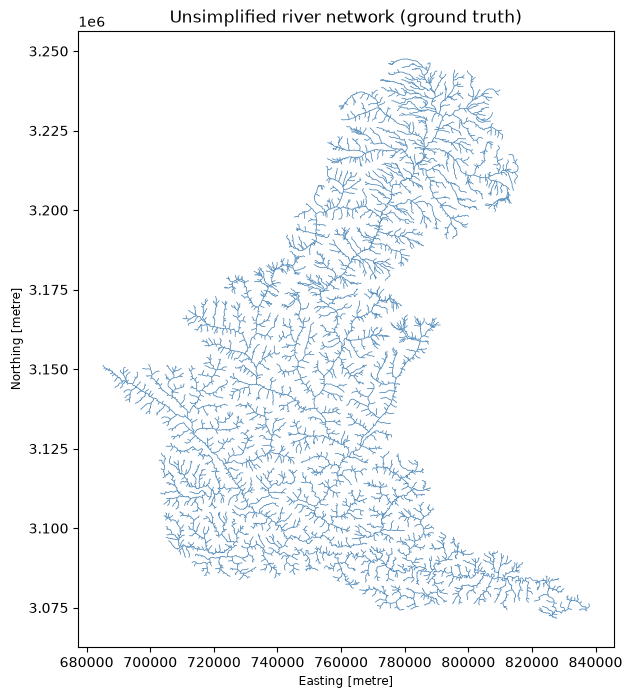

In [15]:
# --- Sanity check: is the ORIGINAL (unsimplified) river network actually connected? ---
import geopandas as gpd
streams_check = gpd.read_file(results_dir / "river_network.gpkg")
print("Total segments:", len(streams_check))

# Quick visual check: plot the unsimplified network to confirm it's not broken
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
streams_check.plot(ax=ax, linewidth=0.5, color="steelblue")
ax.set_title("Unsimplified river network (ground truth)")
plt.show()

Test threshold: 5.0 km² = 5556 cells
.\whitebox_tools.exe --run="RasterStreamsToVector" --wd="D:\HydropowerScreening\results\preprocessing" --streams='D:\HydropowerScreening\results\preprocessing\test_stream_network_5km2.tif' --d8_pntr='D:\HydropowerScreening\results\preprocessing\flowPointer.tif' --output='D:\HydropowerScreening\results\preprocessing\test_stream_network_5km2.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%


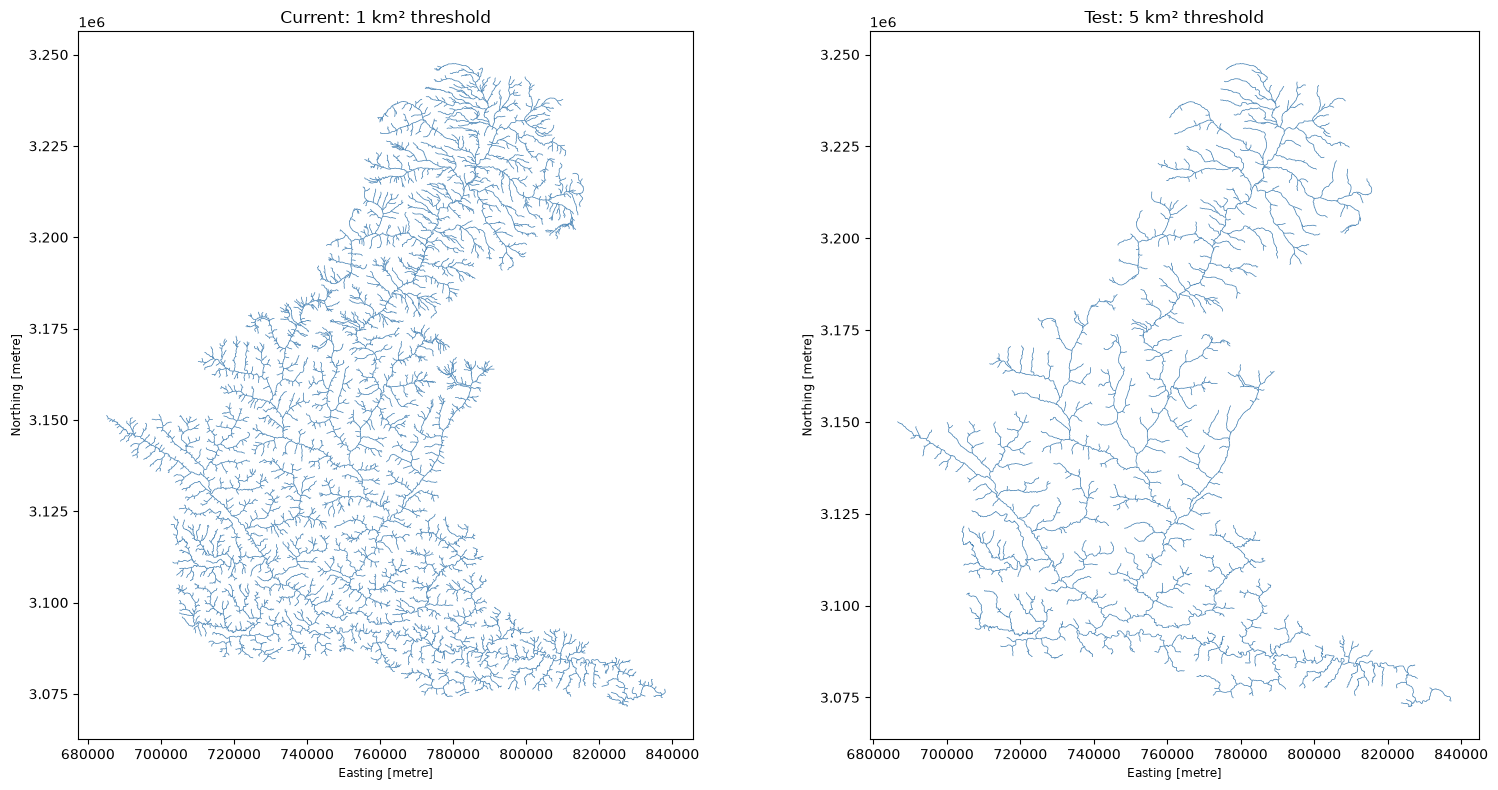

In [16]:
# --- TEST: re-derive stream network at 5 km² threshold (not yet saved as the official version) ---
test_threshold_km2 = 5.0
test_threshold_cells = int(round(test_threshold_km2 / cell_area_km2))
print(f"Test threshold: {test_threshold_km2} km² = {test_threshold_cells} cells")

# --- Build test stream raster masked to watershed ---
test_stream_data = np.where(
    (facc_full >= test_threshold_cells) & valid_ws_mask_full, 1, profile["nodata"]
).astype(profile["dtype"])

test_stream_raster = str((preprocessing_dir / "test_stream_network_5km2.tif").resolve())
with rasterio.open(test_stream_raster, "w", **profile) as dst:
    dst.write(test_stream_data, 1)

# --- Vectorize ---
test_stream_vector = str((preprocessing_dir / "test_stream_network_5km2.shp").resolve())
wbt.raster_streams_to_vector(streams=test_stream_raster, d8_pntr=flow_direction, output=test_stream_vector)

test_streams_gdf = gpd.read_file(test_stream_vector)
test_streams_gdf = test_streams_gdf.set_crs(dem_crs, allow_override=True)

print("Segments at 5 km²:", len(test_streams_gdf))
print("Segments at 1 km² (current):", len(streams_gdf))

# --- Visual comparison, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
streams_gdf.plot(ax=axes[0], linewidth=0.5, color="steelblue")
axes[0].set_title("Current: 1 km² threshold")
test_streams_gdf.plot(ax=axes[1], linewidth=0.5, color="steelblue")
axes[1].set_title("Test: 5 km² threshold")
plt.tight_layout()
plt.show()

Test threshold: 10.0 km² = 11111 cells
.\whitebox_tools.exe --run="RasterStreamsToVector" --wd="D:\HydropowerScreening\results\preprocessing" --streams='D:\HydropowerScreening\results\preprocessing\test_stream_network_10km2.tif' --d8_pntr='D:\HydropowerScreening\results\preprocessing\flowPointer.tif' --output='D:\HydropowerScreening\results\preprocessing\test_stream_network_10km2.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 

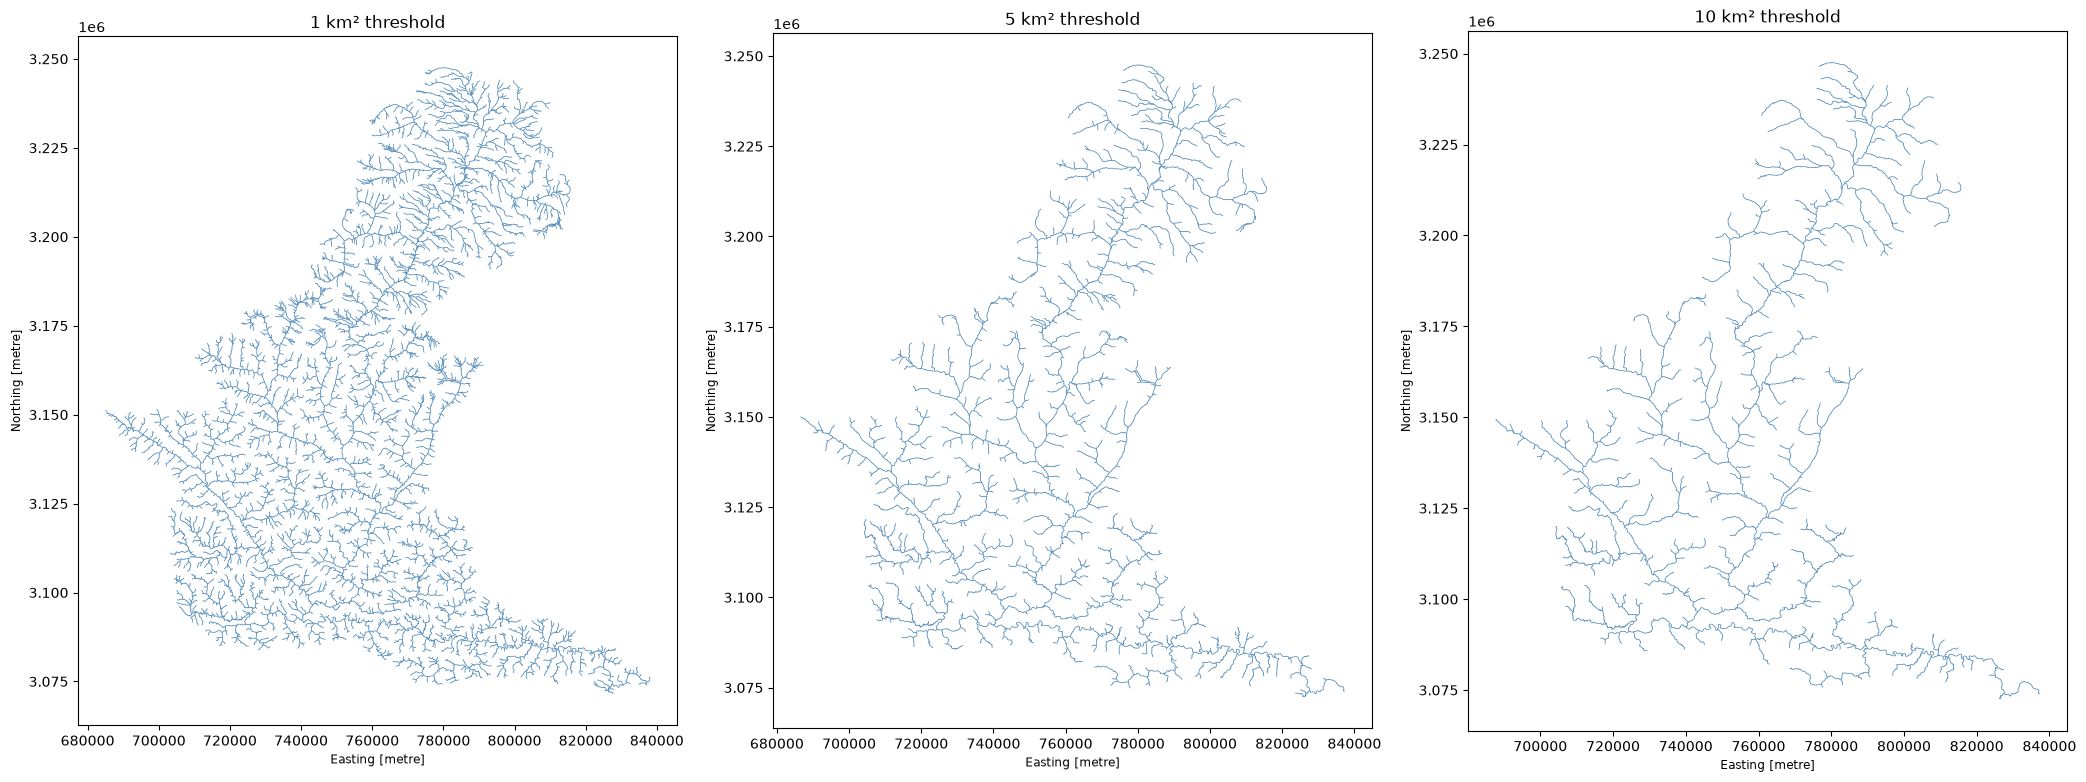

In [17]:
# --- TEST: re-derive stream network at 10 km² threshold (comparison only) ---
test_threshold_km2_10 = 10.0
test_threshold_cells_10 = int(round(test_threshold_km2_10 / cell_area_km2))
print(f"Test threshold: {test_threshold_km2_10} km² = {test_threshold_cells_10} cells")

test_stream_data_10 = np.where(
    (facc_full >= test_threshold_cells_10) & valid_ws_mask_full, 1, profile["nodata"]
).astype(profile["dtype"])

test_stream_raster_10 = str((preprocessing_dir / "test_stream_network_10km2.tif").resolve())
with rasterio.open(test_stream_raster_10, "w", **profile) as dst:
    dst.write(test_stream_data_10, 1)

test_stream_vector_10 = str((preprocessing_dir / "test_stream_network_10km2.shp").resolve())
wbt.raster_streams_to_vector(streams=test_stream_raster_10, d8_pntr=flow_direction, output=test_stream_vector_10)

test_streams_gdf_10 = gpd.read_file(test_stream_vector_10)
test_streams_gdf_10 = test_streams_gdf_10.set_crs(dem_crs, allow_override=True)

print("Segments at 1 km²:", len(streams_gdf))
print("Segments at 5 km²:", len(test_streams_gdf))
print("Segments at 10 km²:", len(test_streams_gdf_10))

# --- Visual comparison, all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(21, 8))
streams_gdf.plot(ax=axes[0], linewidth=0.5, color="steelblue")
axes[0].set_title("1 km² threshold")
test_streams_gdf.plot(ax=axes[1], linewidth=0.5, color="steelblue")
axes[1].set_title("5 km² threshold")
test_streams_gdf_10.plot(ax=axes[2], linewidth=0.5, color="steelblue")
axes[2].set_title("10 km² threshold")
plt.tight_layout()
plt.show()